# ACO — Optimización de rutas con GPU


**Ant Colony Optimization **


In [ ]:
# ============================================================
# CELDA 1: Setup — GPU + imports
# ============================================================
import sys, math, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import clear_output, display

try:
    import cupy as cp
    GPU = True
    print(f" GPU: {cp.cuda.runtime.getDeviceCount()} device(s) disponibles")
    print(f"   Dispositivo: {cp.cuda.Device(0).attributes}" if False else "")
except Exception as e:
    import numpy as cp   # fallback transparente: mismo API
    GPU = False
    print(f"  CPU mode — CuPy no disponible ({e})")
    print("    Para GPU: Runtime → Cambiar tipo de entorno → T4 GPU")

def to_np(arr):
    """CuPy/NumPy → NumPy puro (para matplotlib)."""
    return cp.asnumpy(arr) if GPU else np.asarray(arr)

print(f"\nBackend activo: {'CuPy (GPU)' if GPU else 'NumPy (CPU)'}")

 GPU: 1 device(s) disponibles


Backend activo: CuPy (GPU)


In [ ]:
# ============================================================
# CELDA 2: Mapa
# 0=libre  1=pared  2=colonia(inicio)  3=comida(destino)
# ============================================================
GRID = np.array([
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3, 0],
    [0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
], dtype=np.int32)

print(f"Grid: {GRID.shape[0]}x{GRID.shape[1]}")
print(f"Colonia (inicio) : {tuple(np.argwhere(GRID==2)[0])}")
print(f"Comida  (destino): {tuple(np.argwhere(GRID==3)[0])}")
print(f"Celdas libres    : {(GRID==0).sum()}")
print(f"Obstáculos       : {(GRID==1).sum()}")

Grid: 11x15
Colonia (inicio) : (np.int64(9), np.int64(1))
Comida  (destino): (np.int64(1), np.int64(13))
Celdas libres    : 140
Obstáculos       : 23


In [ ]:
# ============================================================
# CELDA 3: Algoritmo ACO — Hormigas vectorizadas en GPU
# ============================================================

class ACO:
    """
    ACO vectorizado: todas las N hormigas se mueven en paralelo cada tick.

    Parámetros
    ----------
    N        : cantidad de hormigas
    M        : iteraciones totales
    alpha    : peso de feromonas  (τ^α)
    beta     : peso de heurística (η^β)
    rho      : tasa de evaporación ρ
    tau_init : nivel inicial de feromonas τ₀
    max_steps: pasos máximos por hormiga por iteración
    """

    # 8-conectividad: (Δrow, Δcol)
    DIRS = np.array([[-1,-1],[-1,0],[-1,1],
                     [ 0,-1],       [ 0,1],
                     [ 1,-1],[ 1,0],[ 1,1]], dtype=np.int32)
    N_DIRS = 8

    def __init__(self, grid, N=30, M=100,
                 alpha=3.0, beta=1.0, rho=0.1,
                 tau_init=0, max_steps=None):

        self.grid_np  = grid.copy()
        self.rows, self.cols = grid.shape
        self.N, self.M       = N, M
        self.alpha, self.beta, self.rho = alpha, beta, rho
        self.max_steps = max_steps or (self.rows * self.cols * 2)

        # Origen y destino
        self.colony = tuple(np.argwhere(grid == 2)[0])
        self.food   = tuple(np.argwhere(grid == 3)[0])

        # ── GPU: matriz de feromonas ──────────────────────────────
        # Shape (rows, cols) — toda op sobre esta matriz va a GPU
        pher_np = np.ones((self.rows, self.cols), dtype=np.float32) * tau_init
        pher_np[grid == 1] = 0.0
        self.pheromones = cp.array(pher_np)           # vive en VRAM

        # ── GPU: heurística η_{r,c} = 1 / dist_euclidiana_al_destino
        self.heuristic = cp.array(self._build_heuristic())  # vive en VRAM

        # ── GPU: máscara de celdas transitables (0/1)
        self.passable = cp.array((grid != 1).astype(np.float32))  # VRAM

        # ── GPU: offsets de vecinos pre-cargados en GPU
        self.dirs_gpu = cp.array(self.DIRS)            # shape (8,2)

        # Estado de la simulación
        self.best_path   = None
        self.best_length = float('inf')
        self.iteration   = 0
        self.active_paths_sample = []   # muestra para visualización

    # ------------------------------------------------------------------
    def _build_heuristic(self):
        """η_{r,c} = 1 / distancia_euclidiana_al_destino."""
        fr, fc = self.food
        rows_idx = np.arange(self.rows).reshape(-1, 1)
        cols_idx = np.arange(self.cols).reshape(1, -1)
        dist = np.sqrt((rows_idx - fr)**2 + (cols_idx - fc)**2) + 1e-6
        eta  = 1.0 / dist
        eta[self.grid_np == 1] = 0.0
        return eta.astype(np.float32)

    # ------------------------------------------------------------------
    def _vectorized_ants(self):
        """
        Mueve las N hormigas EN PARALELO en GPU.

        Estrategia:
        -----------
        • ant_r, ant_c : arrays GPU shape (N,) — posición actual de cada hormiga
        • visited      : array GPU shape (N, rows, cols) bool — celdas ya visitadas
        • alive        : array GPU shape (N,) bool — hormiga aún en movimiento
        • found        : array GPU shape (N,) bool — llegó a la comida
        • paths        : list de N listas Python — se llena solo para las que llegan
                         (necesitamos el camino para el depósito)

        En cada tick:
        1. Para cada una de las 8 direcciones, calculamos la posición candidata
           de todas las hormigas vivas → arrays (N, 8)
        2. Aplicamos máscara: fuera de bounds + paredes + ya visitadas → score=0
        3. score = τ^α · η^β  — todo en GPU
        4. Gumbel-max trick: sample = argmax(log(score) + Gumbel(0,1))
           → selecciona dirección para cada hormiga, todo en GPU
        5. Actualizamos posición, visited, alive, found
        6. Guardamos historial de posiciones para el depósito posterior
        """
        N = self.N
        cr, cc = self.colony
        fr, fc = self.food

        # Posiciones: shape (N,)
        ant_r = cp.full(N, cr, dtype=cp.int32)
        ant_c = cp.full(N, cc, dtype=cp.int32)

        # Historial de posiciones: guardar como lista de arrays para reconstruir caminos
        # shape (max_steps+1, N, 2) — posición en cada tick
        history_r = cp.full((self.max_steps + 1, N), cr, dtype=cp.int32)
        history_c = cp.full((self.max_steps + 1, N), cc, dtype=cp.int32)

        # Máscaras de estado
        alive = cp.ones(N, dtype=cp.bool_)    # hormiga en movimiento
        found = cp.zeros(N, dtype=cp.bool_)   # llegó a la comida
        step_found = cp.full(N, self.max_steps + 1, dtype=cp.int32)  # tick en que llegó

        # Visited: shape (N, rows*cols) — usamos índice lineal para eficiencia
        visited = cp.zeros((N, self.rows * self.cols), dtype=cp.bool_)
        visited[:, cr * self.cols + cc] = True

        # Offsets de las 8 direcciones en GPU
        dr = self.dirs_gpu[:, 0]   # shape (8,)
        dc = self.dirs_gpu[:, 1]   # shape (8,)

        for step in range(1, self.max_steps + 1):
            if not cp.any(alive):
                break

            # Candidatos: shape (N, 8)
            # nr[i, d] = fila candidata para hormiga i en dirección d
            nr = ant_r[:, None] + dr[None, :]   # (N, 8)
            nc = ant_c[:, None] + dc[None, :]   # (N, 8)

            # Máscara 1: dentro de los límites del grid
            in_bounds = (
                (nr >= 0) & (nr < self.rows) &
                (nc >= 0) & (nc < self.cols)
            )  # (N, 8)

            # Clamp para indexar sin error (las que están fuera quedan en 0,0)
            nr_safe = cp.clip(nr, 0, self.rows - 1)
            nc_safe = cp.clip(nc, 0, self.cols - 1)
            linear  = nr_safe * self.cols + nc_safe   # (N, 8)

            # Máscara 2: celda transitable (no pared)
            passable_mask = self.passable[nr_safe, nc_safe] > 0   # (N, 8)

            # Máscara 3: no visitada por esta hormiga
            # visited shape (N, rows*cols), linear shape (N, 8)
            not_visited = ~cp.take_along_axis(
                visited, linear, axis=1
            )  # (N, 8)

            # Máscara combinada
            valid = in_bounds & passable_mask & not_visited   # (N, 8)

            # ── Score = τ^α · η^β  (todo en GPU) ─────────────────
            tau = self.pheromones[nr_safe, nc_safe]   # (N, 8)
            eta = self.heuristic[nr_safe, nc_safe]    # (N, 8)

            score = (tau ** self.alpha) * (eta ** self.beta)   # (N, 8)
            score = score * valid.astype(cp.float32)           # zerar inválidos

            # ── Gumbel-max trick: muestreo categórico en GPU ──────
            # Para cada hormiga, elige la dirección con
            # argmax(log(score + ε) + Gumbel(0,1))
            # Esto es equivalente a sample de Categorical(score/sum)
            # cp.random.uniform no acepta dtype en NumPy fallback,
            # generamos float64 y casteamos — compatible con ambos backends
            _u = cp.random.uniform(size=(N, self.N_DIRS)).astype(cp.float32)
            gumbel = -cp.log(-cp.log(_u + 1e-10) + 1e-10)
            log_score = cp.log(score + 1e-10) + gumbel
            # Hormigas sin movimientos válidos → score todo 0 → elegirán dir 0 (inválida)
            has_valid = valid.any(axis=1)   # (N,)

            chosen_dir = cp.argmax(log_score, axis=1)   # (N,) índice 0-7

            # Nueva posición
            new_r = ant_r + dr[chosen_dir]   # (N,)
            new_c = ant_c + dc[chosen_dir]   # (N,)

            # Solo mover las hormigas vivas con movimientos válidos
            can_move = alive & has_valid

            ant_r = cp.where(can_move, new_r, ant_r)
            ant_c = cp.where(can_move, new_c, ant_c)

            # Marcar visitado
            new_linear = ant_r * self.cols + ant_c   # (N,)
            # Solo para las que se movieron
            moved_idx = cp.where(can_move)[0]
            if moved_idx.size > 0:
                visited[moved_idx, new_linear[moved_idx]] = True

            # Guardar posición en historial
            history_r[step] = ant_r
            history_c[step] = ant_c

            # Detectar llegada a comida
            just_arrived = can_move & (ant_r == fr) & (ant_c == fc) & ~found
            step_found   = cp.where(just_arrived, cp.int32(step), step_found)
            found        = found | just_arrived

            # Hormigas que llegaron o se atascaron dejan de moverse
            alive = alive & ~found & can_move

        # ── Reconstruir caminos de las hormigas exitosas ──────────
        # Transferir historial a CPU solo una vez al final
        history_r_np  = to_np(history_r)    # (max_steps+1, N)
        history_c_np  = to_np(history_c)
        found_np      = to_np(found)         # (N,) bool
        step_found_np = to_np(step_found)    # (N,) int

        paths = []
        for i in range(N):
            if found_np[i]:
                length = int(step_found_np[i]) + 1
                path   = [(int(history_r_np[s, i]), int(history_c_np[s, i]))
                          for s in range(length)]
                paths.append(path)

        return paths

    # ------------------------------------------------------------------
    def step(self):
        """
        Una iteración completa:
        1. Mover N hormigas en paralelo (GPU)
        2. Evaporar feromonas (GPU)
        3. Depositar feromonas (GPU)
        """
        # 1. Movimiento vectorizado en GPU
        paths = self._vectorized_ants()

        # Actualizar mejor camino
        for p in paths:
            if len(p) < self.best_length:
                self.best_length = len(p)
                self.best_path   = p[:]

        # Guardar muestra para visualización (máx 12)
        self.active_paths_sample = paths[:12]

        # 2. Evaporación vectorizada en GPU: τ = (1 - ρ) · τ
        self.pheromones = (1.0 - self.rho) * self.pheromones

        # 3. Depósito vectorizado en GPU: Δτ = 1 / longitud_camino
        if paths:
            deposit = cp.zeros((self.rows, self.cols), dtype=cp.float32)
            for p in paths:
                amount = cp.float32(1.0 / len(p))
                rs = [x[0] for x in p]
                cs = [x[1] for x in p]
                cp.add.at(deposit, (rs, cs), amount)
            self.pheromones = self.pheromones + deposit

        self.iteration += 1
        return len(paths)

In [ ]:
# ============================================================
# CELDA 4: Visualización matplotlib
# ============================================================
_CMAP = plt.cm.Purples

COL_WALL   = np.array([0.08, 0.08, 0.12, 1.0])
COL_COLONY = np.array([0.00, 0.90, 0.42, 1.0])  # verde
COL_FOOD   = np.array([1.00, 0.10, 0.27, 1.0])  # rojo


def build_canvas(aco):
    pher  = to_np(aco.pheromones)
    max_p = pher.max() if pher.max() > 0 else 1.0
    norm  = pher / max_p
    canvas = np.ones((aco.rows, aco.cols, 4))
    for r in range(aco.rows):
        for c in range(aco.cols):
            v = aco.grid_np[r, c]
            if   v == 1: canvas[r, c] = COL_WALL
            elif v == 2: canvas[r, c] = COL_COLONY
            elif v == 3: canvas[r, c] = COL_FOOD
            else:        canvas[r, c] = _CMAP(0.1 + norm[r, c] * 0.9)
    return canvas


def render(aco, ax, img_obj):
    img_obj.set_data(build_canvas(aco))
    for artist in ax._dynamic:
        artist.remove()
    ax._dynamic.clear()

    # Mejor camino: línea amarilla
    if aco.best_path:
        bp = np.array(aco.best_path)
        line, = ax.plot(bp[:, 1], bp[:, 0], '-o',
                        color='#FFD600', linewidth=1.6,
                        markersize=3, alpha=0.95, zorder=3)
        ax._dynamic.append(line)

    # Posición final de hormigas activas: naranja
    for path in aco.active_paths_sample:
        if path:
            r, c = path[-1]
            dot, = ax.plot(c, r, 'o', color='#FF6D00',
                           markersize=7, zorder=4)
            ax._dynamic.append(dot)

    best_str = str(aco.best_length) if aco.best_length < float('inf') else 'N/A'
    ax.set_title(
        f'Iteración {aco.iteration}/{aco.M}   '
        f'Mejor ruta: {best_str} pasos   '
        f'Hormigas exitosas: {len(aco.active_paths_sample)}/{aco.N}',
        fontsize=11, color='white'
    )


def setup_axes(aco):
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('#0d0d1a')
    ax.set_facecolor('#0d0d1a')

    img = ax.imshow(
        build_canvas(aco),
        origin='upper', aspect='equal',
        extent=[-0.5, aco.cols - 0.5, aco.rows - 0.5, -0.5]
    )

    ax.set_xticks(np.arange(-0.5, aco.cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, aco.rows, 1), minor=True)
    ax.grid(which='minor', color='#1e1e3a', linewidth=0.5)
    ax.tick_params(which='both', bottom=False, left=False,
                   labelbottom=False, labelleft=False)

    legend = [
        mpatches.Patch(color='#00E676', label='Colonia (inicio)'),
        mpatches.Patch(color='#FF1744', label='Comida (destino)'),
        mpatches.Patch(color='#1a1a2e', label='Pared'),
        mpatches.Patch(color='#9B59B6', label='Feromonas'),
        mpatches.Patch(color='#FFD600', label='Mejor ruta'),
        mpatches.Patch(color='#FF6D00', label='Hormiga activa'),
    ]
    ax.legend(handles=legend, loc='lower right',
              fontsize=9, framealpha=0.7,
              facecolor='#1a1a2e', labelcolor='white')

    ax._dynamic = []
    return fig, ax, img

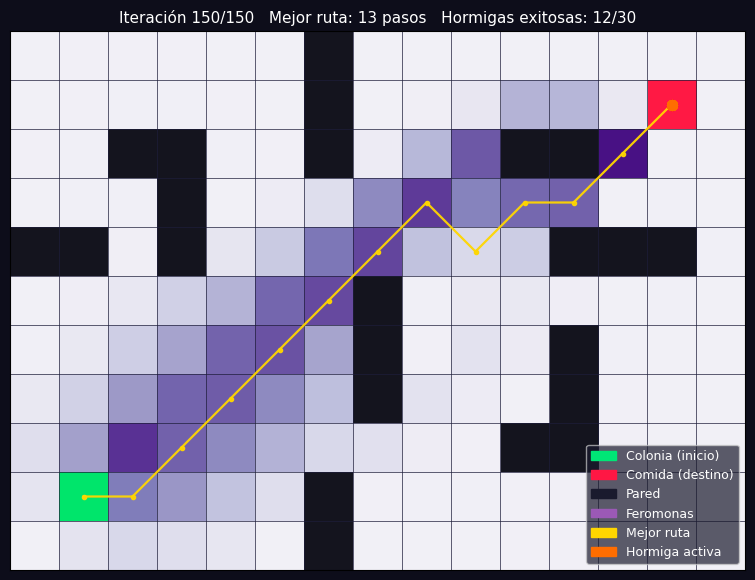

Tiempo total : 27.57s
Tiempo/iter  : 183.8ms
Mejor ruta   : 13 pasos
Camino: (9, 1) -> (9, 2) -> (8, 3) -> (7, 4) -> (6, 5) -> (5, 6) -> (4, 7) -> (3, 8) -> (4, 9) -> (3, 10) -> (3, 11) -> (2, 12) -> (1, 13)


In [ ]:
# ============================================================
# CELDA 5: Parámetros + ejecución con animación
# ============================================================
PARAMS = dict(
    N        = 30,    # hormigas (todas se mueven en paralelo en GPU)
    M        = 150,   # iteraciones
    alpha    = 1.0,   # importancia de feromonas
    beta     = 3.0,   # importancia de heurística
    rho      = 0.1,   # tasa de evaporación
    tau_init = 1.0,   # feromonas iniciales
)
RENDER_EVERY = 5   # redibujar cada N iteraciones

aco = ACO(GRID, **PARAMS)
fig, ax, img = setup_axes(aco)

print(f"Backend : {'CuPy (GPU)' if GPU else 'NumPy (CPU)'}")
print(f"Hormigas: {PARAMS['N']} (vectorizadas — se mueven en paralelo)")
print(f"Iters   : {PARAMS['M']}")
print()

t0 = time.time()

for i in range(PARAMS['M']):
    n_found = aco.step()

    if (i + 1) % RENDER_EVERY == 0 or i == 0:
        render(aco, ax, img)
        clear_output(wait=True)
        display(fig)

# Frame final
render(aco, ax, img)
clear_output(wait=True)
display(fig)
plt.close(fig)

elapsed = time.time() - t0
print(f"Tiempo total : {elapsed:.2f}s")
print(f"Tiempo/iter  : {elapsed/PARAMS['M']*1000:.1f}ms")
print(f"Mejor ruta   : {aco.best_length} pasos")
print("Camino:", ' -> '.join(str(p) for p in (aco.best_path or [])))

In [ ]:
# ============================================================
# CELDA 6: Benchmark GPU vs CPU
# ============================================================
import numpy as _np_bench

BP = dict(N=50, M=80, alpha=1.0, beta=3.0, rho=0.1, tau_init=1.0)

def run_bench(use_gpu, params):
    """Corre ACO en modo headless (sin animación) midiendo tiempo."""
    global cp, GPU
    _cp_bak, _gpu_bak = cp, GPU

    if not use_gpu:
        cp, GPU = _np_bench, False

    a  = ACO(GRID, **params)
    t0 = time.time()
    for _ in range(params['M']):
        a.step()
    t = time.time() - t0

    cp, GPU = _cp_bak, _gpu_bak
    return t, a.best_length

print("Benchmark (sin animación)...")
print(f"N={BP['N']} hormigas, M={BP['M']} iters")
print("-" * 45)

t_cpu, b_cpu = run_bench(False, BP)
print(f"CPU (NumPy) : {t_cpu:.3f}s  |  mejor: {b_cpu} pasos")

if GPU:
    t_gpu, b_gpu = run_bench(True, BP)
    print(f"GPU (CuPy)  : {t_gpu:.3f}s  |  mejor: {b_gpu} pasos")
    speedup = t_cpu / t_gpu
    print(f"Speedup     : {speedup:.2f}x  ", end="")
    print(" GPU más rápida" if speedup > 1 else "  CPU más rápida (grid pequeño)")
    print()
    print("Nota: En grids pequeños el overhead de CuPy puede superar el beneficio.")
    print("Con grids >= 100x100 y N >= 200 hormigas, la GPU gana claramente.")
else:
    print("GPU no disponible — activa runtime T4 en Colab")

Benchmark (sin animación)...
N=50 hormigas, M=80 iters
---------------------------------------------
CPU (NumPy) : 0.868s  |  mejor: 14 pasos
